# Synchronize and Resample Raw IMU + Odometry Data Then save it into one CSV file

**Function**: Synchronize raw IMU (ACC and GYRO) and odometry onto one timeline.

## Strategy

1. Load raw runs from `data/raw/Test/` (and other dataset subdirectories)
2. Determine target sample rate (e.g., 100 Hz based on QC criteria)
3. Create unified time grid from min(t_rel) to max(t_rel) across all sensors
4. Interpolate each sensor to the common grid (linear interpolation)
5. Merge the data into one singular file
6. Save the syncronized and merged runs into runs to `data/interim/merged/`

**Input**: Raw sensor logs from `data/raw/`  
**Output**: Synchronized runs with uniform dt for all sensors in `data/interim/merged/`


## Setup


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from dataclasses import replace

# Make project root importable
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io import load_run, load_runs
from src.preprocess import (
    build_dataset_qc_table,
    split_qc_pass_fail,
    qc_report,
    plot_sanity,
)


## Load raw runs

Discover and load all runs from the chosen dataset directory.


In [2]:
# Load the required data for sync_resample_merger

#Main dataset
#raw_data_dir = PROJECT_ROOT / "data" / "raw" / "Main"
#all_raw_runs = load_runs(raw_data_dir, include_pose=False)

#Farm dataset
raw_data_dir = PROJECT_ROOT / "data" / "raw" / "Farm"
all_raw_runs = [load_run(raw_data_dir / "Run1", include_pose=False), load_run(raw_data_dir / "Run2", include_pose=False), load_run(raw_data_dir / "Run3", include_pose=False), load_run(raw_data_dir / "Run4", include_pose=False), load_run(raw_data_dir / "Run5", include_pose=False)]

#Output path
merged_output_path = PROJECT_ROOT / "data" / "interim" / "merged" / "merged_dataset_Farm.csv"

print(f"Total raw runs found: {len(all_raw_runs)}")

# Run QC analysis to identify good runs
dataset_qc = build_dataset_qc_table(all_raw_runs, tcol='t_rel', min_duration_s=30.0)
_, _, good_run_ids, bad_run_ids = split_qc_pass_fail(dataset_qc)

print(f"\n✓ Good runs ({len(good_run_ids)}):")
for run_id in good_run_ids:
    print(f"  - {run_id}")

print(f"\n✗ Bad runs ({len(bad_run_ids)}):")
for run_id in bad_run_ids:
    print(f"  - {run_id}")

# Filter to only good runs for resampling
raw_runs = {run.run_id: run for run in all_raw_runs if run.run_id in good_run_ids}
print(f"\nFiltered to {len(raw_runs)} good runs for resampling")


Total raw runs found: 5

✓ Good runs (5):
  - Run1
  - Run2
  - Run3
  - Run4
  - Run5

✗ Bad runs (0):

Filtered to 5 good runs for resampling


## Resampling helper

Local copy of `resample_sensors()` mirroring `src/preprocess.py` — kept inline for transparency about the interpolation strategy used on each run.


In [ ]:
def resample_sensors(
    acc: pd.DataFrame,
    gyro: pd.DataFrame,
    odo: pd.DataFrame,
    target_hz: float = 100.0,
    tcol: str = "t_rel",
    method: str = "linear",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Resample accelerometer, gyroscope, and odometry to a common sample rate. 
    
    Creates a unified time grid over the intersection of all sensor time ranges. Preserves label column if present.
        
    Returns:
        Tuple of (acc_resampled, gyro_resampled, odo_resampled)
    """

    # Determine the unified time grid
    t_min = min(acc[tcol].min(), gyro[tcol].min(), odo[tcol].min())
    t_max = max(acc[tcol].max(), gyro[tcol].max(), odo[tcol].max())
    dt = 1.0 / target_hz
    
    # Create unified time grid
    unified_time = np.arange(t_min, t_max + dt / 2, dt)
    
    def interpolate_sensor(df: pd.DataFrame, new_time: np.ndarray, tcol: str, method: str) -> pd.DataFrame:
        """Interpolate a sensor DataFrame to new time grid, preserving labels."""
        label_col = "label" if "label" in df.columns else None
        numeric_cols = [c for c in df.columns if c != tcol and c != label_col]
        
        # Interpolate numeric columns
        data_resampled = {}
        for col in numeric_cols:
            if method == "linear":
                data_resampled[col] = np.interp(new_time, df[tcol], df[col])
            elif method == "nearest":
                indices = np.searchsorted(df[tcol], new_time)
                indices = np.clip(indices, 0, len(df) - 1)
                data_resampled[col] = df[col].iloc[indices].values
            else:
                raise ValueError(f"Unknown method: {method}")
        
        # Forward-fill labels (preserve prior labels for resampled points)
        if label_col:
            label_indices = np.searchsorted(df[tcol], new_time, side="right") - 1
            label_indices = np.clip(label_indices, 0, len(df) - 1)
            data_resampled[label_col] = df[label_col].iloc[label_indices].values
        
        # Create resampled DataFrame
        result = pd.DataFrame(data_resampled)
        result.insert(0, tcol, new_time)
        return result.reset_index(drop=True)
    
    # Resample all sensors
    acc_resampled = interpolate_sensor(acc, unified_time, tcol, method)
    gyro_resampled = interpolate_sensor(gyro, unified_time, tcol, method)
    odo_resampled = interpolate_sensor(odo, unified_time, tcol, method)
    
    return acc_resampled, gyro_resampled, odo_resampled

## Resample every run to 100 Hz

Build a unified time grid per run and linearly interpolate acc/gyro/odo onto it.


In [4]:
# Resample all raw runs to 100 Hz
resampled_runs = {}
target_hz = 100.0

for run_id, run in raw_runs.items():
    acc_rs, gyro_rs, odo_rs = resample_sensors(
        run.acc, run.gyro, run.odo,
        target_hz=target_hz,
        tcol="t_rel",
        method="linear"
    )
    
    # Create resampled RunData (no labels since this is raw data)
    run_resampled = replace(run, acc=acc_rs, gyro=gyro_rs, odo=odo_rs, pose=None)
    resampled_runs[run_id] = run_resampled
    
    print(f"\n{run_id} (resampled to {target_hz} Hz):")
    print(f"  ACC: {len(run.acc)} → {len(acc_rs)} samples")
    print(f"  GYRO: {len(run.gyro)} → {len(gyro_rs)} samples")
    print(f"  ODO: {len(run.odo)} → {len(odo_rs)} samples")



Run1 (resampled to 100.0 Hz):
  ACC: 43488 → 52204 samples
  GYRO: 43490 → 52204 samples
  ODO: 43491 → 52204 samples

Run2 (resampled to 100.0 Hz):
  ACC: 75007 → 90033 samples
  GYRO: 75009 → 90033 samples
  ODO: 75014 → 90033 samples

Run3 (resampled to 100.0 Hz):
  ACC: 67453 → 80944 samples
  GYRO: 67453 → 80944 samples
  ODO: 67453 → 80944 samples

Run4 (resampled to 100.0 Hz):
  ACC: 67250 → 80700 samples
  GYRO: 67250 → 80700 samples
  ODO: 67250 → 80700 samples

Run5 (resampled to 100.0 Hz):
  ACC: 136192 → 163432 samples
  GYRO: 136192 → 163432 samples
  ODO: 136193 → 163432 samples


## Merge sensors into one DataFrame per run

Join acc + gyro + odo on the common time grid and stack all runs into a single long-format table tagged with `run_id`.


In [5]:
merged_data = []

for run_id, run in resampled_runs.items():
    # Combine all sensors for this run
    run_data = run.acc.copy()
    
    # Add gyro columns (drop t_rel and t to avoid duplicates)
    gyro_cols = [c for c in run.gyro.columns if c not in ['t_rel', 't']]
    for col in gyro_cols:
        run_data[col] = run.gyro[col]
    
    # Add odo columns (drop t_rel and t to avoid duplicates)
    odo_cols = [c for c in run.odo.columns if c not in ['t_rel', 't']]
    for col in odo_cols:
        run_data[col] = run.odo[col]
    
    # Add run_id column for tracking
    run_data['run_id'] = run_id
    
    merged_data.append(run_data)

# Concatenate all runs
merged_df = pd.concat(merged_data, ignore_index=True)

# Reorder columns: t, t_rel, run_id, then sensor data
sensor_cols = [c for c in merged_df.columns if c not in ['t', 't_rel', 'run_id']]
merged_df = merged_df[['t', 't_rel', 'run_id'] + sensor_cols]

print(f"\nMerged dataset shape: {merged_df.shape}")
print(f"Columns: {list(merged_df.columns)}")
print(f"Total samples: {len(merged_df)}")
print(f"Runs included: {merged_df['run_id'].nunique()}")



Merged dataset shape: (467313, 11)
Columns: ['t', 't_rel', 'run_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'v1', 'v2']
Total samples: 467313
Runs included: 5


## Persist merged dataset

Write the combined long-format CSV to `data/interim/merged/`.


In [6]:
# Save merged dataset
merged_df.to_csv(merged_output_path, index=False)
print(f"\nSaved merged dataset to: {merged_output_path}")

# Display first few rows
merged_df.head()


Saved merged dataset to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/merged/merged_dataset_Farm.csv


,t,t_rel,run_id,ax,ay,az,gx,gy,gz,v1,v2
0,1.776765e+09,0.00,Run1,0.045100,-0.999500,0.006000,-3.615400,-9.824300,-1.360500,-0.0,0.0
1,1.776765e+09,0.01,Run1,0.045043,-1.000359,0.009035,-3.583422,-9.765124,-1.556052,0.0,0.0
2,1.776765e+09,0.02,Run1,0.043609,-1.000624,0.010435,-3.530044,-9.849917,-1.683888,0.0,0.0
3,1.776765e+09,0.03,Run1,0.042780,-0.999864,0.008805,-3.440862,-9.907412,-1.692812,0.0,0.0
4,1.776765e+09,0.04,Run1,0.048900,-0.999263,0.008000,-3.336847,-9.707005,-1.661626,0.0,0.0


## QC after resampling

Re-run `qc_report` on the resampled frames to confirm uniform dt and no introduced gaps.


In [7]:
# Generate QC report for resampled good runs
for run_id, run in resampled_runs.items():
    report = qc_report(run.sensors(), tcol="t_rel")
    print(f"\n{run_id} QC Report:")
    print(report.to_string())



Run1 QC Report:
  sensor      n  duration_s  fs_med_hz  dt_med  dt_p99  dt_max  gap_ratio_dtmax_over_dtmed  n_gaps_gt_factor_times_med
0    acc  52204      522.03      100.0    0.01    0.01    0.01                         1.0                           0
1   gyro  52204      522.03      100.0    0.01    0.01    0.01                         1.0                           0
2    odo  52204      522.03      100.0    0.01    0.01    0.01                         1.0                           0

Run2 QC Report:
  sensor      n  duration_s  fs_med_hz  dt_med  dt_p99  dt_max  gap_ratio_dtmax_over_dtmed  n_gaps_gt_factor_times_med
0    acc  90033      900.32      100.0    0.01    0.01    0.01                         1.0                           0
1   gyro  90033      900.32      100.0    0.01    0.01    0.01                         1.0                           0
2    odo  90033      900.32      100.0    0.01    0.01    0.01                         1.0                           0

Run3 QC Repor

## Optional: sanity plot for one resampled run


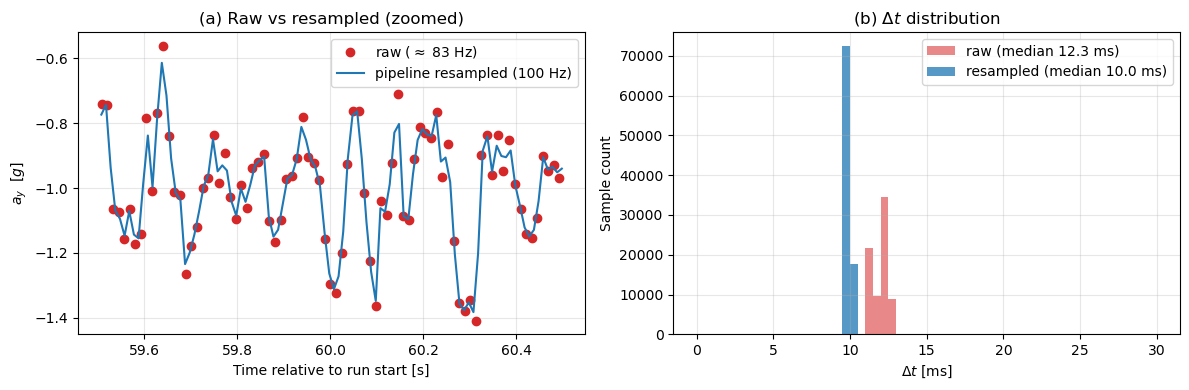

In [ ]:
# Optional: Plot sanity check for one of the resampled runs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent

# Paths
RUN_ID      = "Run2"
ACC_FILE    = PROJECT_ROOT / "data" / "raw" / "Farm" / RUN_ID / "log_t0_acc_1.txt"
MERGED_FILE = PROJECT_ROOT / "data" / "interim" / "merged" / "merged_dataset_Farm.csv"


acc_raw = pd.read_csv(
    ACC_FILE, sep=r"\s+", comment="%", header=None,
    names=["t", "ax", "ay", "az"],
)

# Load the pipeline's merged/resampled output
merged = pd.read_csv(MERGED_FILE)
run_rs = merged[merged["run_id"] == RUN_ID].reset_index(drop=True)

# Align both to the same origin (raw acc's first Unix timestamp)
t0_abs    = acc_raw["t"].iloc[0]
t_raw_rel = acc_raw["t"].to_numpy() - t0_abs
t_rs_rel  = run_rs["t"].to_numpy()  - t0_abs
ay_raw    = acc_raw["ay"].to_numpy()
ay_rs     = run_rs["ay"].to_numpy()

# Δt distributions
dt_raw = np.diff(acc_raw["t"].to_numpy())   * 1000.0   # ms
dt_rs  = np.diff(run_rs["t_rel"].to_numpy()) * 1000.0  # ms

# Plot
ZOOM_CENTER = 60.0    # seconds
ZOOM_HALF   = 0.5    # ±0.5 s

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel (a): raw points overlaid with the pipeline's resampled line
ax_a = axes[0]
m_raw = (t_raw_rel >= ZOOM_CENTER - ZOOM_HALF) & (t_raw_rel <= ZOOM_CENTER + ZOOM_HALF)
m_rs  = (t_rs_rel  >= ZOOM_CENTER - ZOOM_HALF) & (t_rs_rel  <= ZOOM_CENTER + ZOOM_HALF)
ax_a.plot(t_raw_rel[m_raw], ay_raw[m_raw], "o", ms=6, color="C3",
          label=r"raw ($\approx$ 83 Hz)")
ax_a.plot(t_rs_rel[m_rs],  ay_rs[m_rs],  "-", lw=1.5, color="C0",
          label="pipeline resampled (100 Hz)")
ax_a.set_xlabel("Time relative to run start [s]")
ax_a.set_ylabel(r"$a_y$  [$g$]")
ax_a.set_title("(a) Raw vs resampled (zoomed)")
ax_a.legend(loc="best")
ax_a.grid(True, alpha=0.3)

# Panel (b): Δt histograms before vs after
ax_b = axes[1]
bins = np.linspace(0, 30, 61)
ax_b.hist(dt_raw, bins=bins, alpha=0.55, color="C3",
          label=f"raw (median {np.median(dt_raw):.1f} ms)")
ax_b.hist(dt_rs,  bins=bins, alpha=0.75, color="C0",
          label=f"resampled (median {np.median(dt_rs):.1f} ms)")
ax_b.set_xlabel(r"$\Delta t$ [ms]")
ax_b.set_ylabel("Sample count")
ax_b.set_title(r"(b) $\Delta t$ distribution")
ax_b.legend(loc="best")
ax_b.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()